# 병렬처리 워크플로 구현 : 날씨, 뉴스, 주식 

In [ ]:
# 왜 병렬 처리 필요?
# LLM 호출 실행, API 호출, DB 접근, 파일 처리...  <- 처리시간이 오래 걸리는 작업
# 이런작업들은 '순차적'으로 실행하면 느리다!
# 병렬로 동시에 실행하여 워크플로의 성능을 극대화.

# 랭그래프는 각 노드들을 '독립적'으로 실행 할수도 있다!
# 다른 노드에 의존성이 없는 노드는 자동적으로 병렬 실행 할수 있게 됩니다


# import

In [1]:
from dotenv import load_dotenv
print(load_dotenv())

from typing import Dict, Any
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
import time
import random
from IPython.display import Image, display

True


# 상태 정의

In [2]:
class DashboardState(BaseModel):
    user_location: str = "서울"   # 사용자의 위치
    
    weather_data: Dict[str, Any] = {}  # 날씨 데이터
    news_data: Dict[str, Any] = {}   # 뉴스 데이터
    stock_data: Dict[str, Any] = {}  # 주식 관련 데이터

    dashboard_report: str = ""   # 대시보드 리포트

    start_time: float = 0.0   # 대시보드 생성시각

# coorinator 노드
- 병렬처리 시작점
- `시작시간` 업데이트 -> 전체 실행시간 측정에 사용할거다.

In [3]:
def coordinator(state: DashboardState) -> Dict[str, Any]:
    print(f"🟦 대시보드 생성 시작 - 위치: {state.user_location}")
    return {"start_time": time.time()}   # 시작시간 업데이트

# 병렬 실행할 노드(들)

In [ ]:
# 실제 API 를 호출하진 않고,  시간이 걸리는 작업에 대한 시뮬레이션

In [4]:
# 병렬실행할 노드1 - 날씨 데이터 수집
def weather_checker(state: DashboardState) -> Dict[str, Any]:
    print('🌐날씨 확인 중...')
    time.sleep(random.uniform(1.0, 2.0))  # 딜레이

    weather_info = {
        "location": state.user_location,
        "condition": "맑음",
        "temperature": 22,
        "humidity": 65,        
    }
    print(f"🌐날씨: {weather_info['condition']}, {weather_info['temperature']}°C")
    return {"weather_data": weather_info}

In [5]:
# 병렬실행할 노드2 - 뉴스 데이터 수집
def news_fetcher(state: DashboardState) -> Dict[str, Any]:
    print('🎃뉴스 수집 중...')
    time.sleep(random.uniform(1.5, 2.5))  # 딜레이

    news_info = {
        "articles": [
            {"title": "AI 기술 발전 소식", "summary": "AI 분야 새로운 혁신"},
            {"title": "경제 동향 분석", "summary": "글로벌 경제 전망"},
        ],
        "count": 2,
    }
    print(f"🎃뉴스: {news_info['count']}개 수집 완료")
    return {"news_data": news_info}

In [6]:
# 병렬실행할 노드3 - 주식 데이터 분석
def stock_analyzer(state: DashboardState) -> Dict[str, Any]:
    print('💦주식 분석 중...')
    time.sleep(random.uniform(2.0, 3.0))  # 딜레이

    stock_info = {
        "KOSPI": {"close": 7847, "change": +1.2},
        "NASDAQ": {"close": 17080.3, "change": -0.8},
    }
    
    print(f"💦주식 분석 완료.")
    return {"stock_data": stock_info}

# aggregator(집계) 노드

In [ ]:
# '모든' 병렬 실행노드들의 작업이 끝나면 집계 노드가 실행된다.
#  수집된 데이터를 종합하여 리포트 생성.  전체 실행시간 계산

In [7]:
def aggregator(state: DashboardState) -> Dict[str, Any]:
    print('🟦 리포트 생성 중.')

    elapsed_time = time.time() - state.start_time  # 실행시간 측정

    report = f"""
대시보드 리포트
날씨: {state.weather_data.get("condition", "N/A")} {state.weather_data.get("temperature", "N/A")}°C
뉴스: {state.news_data.get("count", 0)}개 기사
주식: KOSPI {state.stock_data.get("KOSPI", {}).get("close", "N/A")}
실행시간: {elapsed_time:.1f}초
    
    """

    print(f"  대시보드 완료 ({elapsed_time:.1f}초)")
    return {"dashboard_report": report}

    

# 그래프 정의

In [10]:
def create_graph():
    workflow = StateGraph(DashboardState)

    # 노드 추가
    workflow.add_node("coordinator", coordinator)
    workflow.add_node("weather", weather_checker)
    workflow.add_node("news", news_fetcher)
    workflow.add_node("stock", stock_analyzer)
    workflow.add_node("aggregator", aggregator)

    # 엣지 연결 : 병렬실행구조 
    workflow.add_edge(START, "coordinator")

    # "coordinator" 실행후 weather, news, stock 이 병렬실행
    workflow.add_edge("coordinator", "weather")
    workflow.add_edge("coordinator", "news")
    workflow.add_edge("coordinator", "stock")

    # weather, news, stock 이 '모두 실행된 뒤'에 aggregator 실행
    workflow.add_edge("weather", "aggregator")
    workflow.add_edge("news", "aggregator")
    workflow.add_edge("stock", "aggregator")
    
    workflow.add_edge("aggregator", END)
    
    
    return workflow.compile()

# 그래프 생성 및 실행

In [14]:
def main():
    print("=== LangGraph 병렬 실행 예제 ===\n")

    app = create_graph()

    initial_state = DashboardState(user_location='부산')
    print("병렬실행시작!")
    result = app.invoke(initial_state)
    print("\n최종결과")
    print(result["dashboard_report"])

    return app

app = main()


=== LangGraph 병렬 실행 예제 ===

병렬실행시작!
🟦 대시보드 생성 시작 - 위치: 부산
🎃뉴스 수집 중...
💦주식 분석 중...
🌐날씨 확인 중...
🌐날씨: 맑음, 22°C
💦주식 분석 완료.
🎃뉴스: 2개 수집 완료
🟦 리포트 생성 중.
  대시보드 완료 (2.2초)

최종결과

대시보드 리포트
날씨: 맑음 22°C
뉴스: 2개 기사
주식: KOSPI 7847
실행시간: 2.2초

    


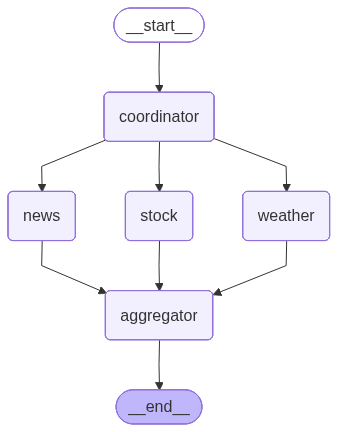

In [15]:
Image(app.get_graph().draw_mermaid_png())